1) Loading the Taxis Dataset

In [62]:
import seaborn as sns

# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

In [63]:
df.head()    # will show first 5 rows of the dataset, is successfully loaded inside python.

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


2) Handling Missing Values

In [64]:
df.isnull().sum()    # Check for missing values in each column

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [65]:
df.dtypes    # Check the data type of the columns with missing values

pickup             datetime64[us]
dropoff            datetime64[us]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                         str
payment                       str
pickup_zone                   str
dropoff_zone                  str
pickup_borough                str
dropoff_borough               str
dtype: object

In [66]:
# Fill categorical missing values using mode
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])
df['pickup_zone'] = df['pickup_zone'].fillna(df['pickup_zone'].mode()[0])
df['dropoff_zone'] = df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0])
df['pickup_borough'] = df['pickup_borough'].fillna(df['pickup_borough'].mode()[0])
df['dropoff_borough'] = df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0])

In [67]:
df.isnull().sum()   # Verify

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

Removing Rows with Missing Values

No rows were removed because all missing values were found in categorical columns (payment, pickup_zone, dropoff_zone, pickup_borough, and dropoff_borough) and could be reasonably imputed using the mode.

Therefore, removing rows was not necessary to maintain data integrity.

3) Visualizations using Matplotlib/Pandas Plot:

1. Line Chart

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

A line chart shows how a value changes over time. It answers "do fares go up, go down, or stay stable, and are there unusual spikes?"

In [69]:
df['pickup'] = pd.to_datetime(df['pickup'])

In [70]:
df['date'] = df['pickup'].dt.date

In [71]:
daily_fare = df.groupby('date')['fare'].mean().reset_index()

In [72]:
daily_fare.head()

,date,fare
0,2019-02-28,5.000000
1,2019-03-01,12.228091
2,2019-03-02,11.909091
3,2019-03-03,12.946095
4,2019-03-04,13.659298


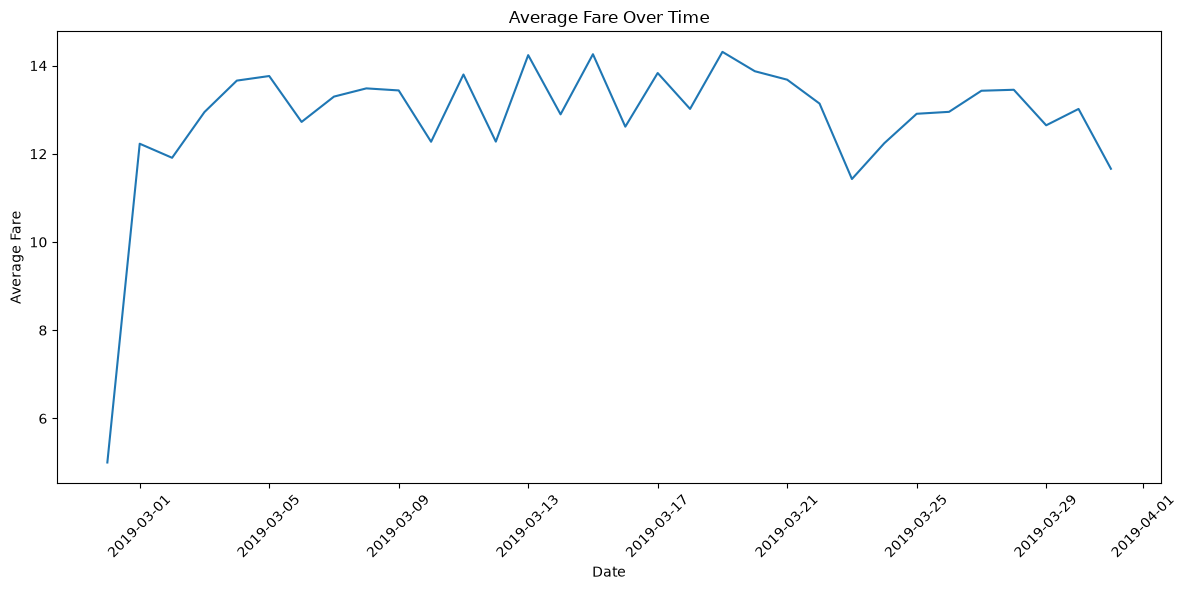

In [73]:
plt.figure(figsize=(12, 6))
plt.plot(daily_fare['date'], daily_fare['fare'])
plt.xlabel('Date')
plt.ylabel('Average Fare')
plt.title('Average Fare Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight - The line chart shows that taxi fares stay fairly stable throughout March 2019, with most fares between $5 and $50 and no clear upward or downward trend. A small number of very high fares, reaching about $150, appear as isolated spikes, likely long-distance trips.

2. Bar Chart

1. Use the pickup_borough column, which says where each trip started.
2. Group the data by borough (groupby('pickup_borough')).
3. Sum the fare within each group, so you get the total money earned from trips starting in each borough.
4. Show those totals as bars, one per borough.

pickup_borough
Manhattan    59426.42
Queens       16382.06
Brooklyn      6327.48
Bronx         2078.91
Name: fare, dtype: float64


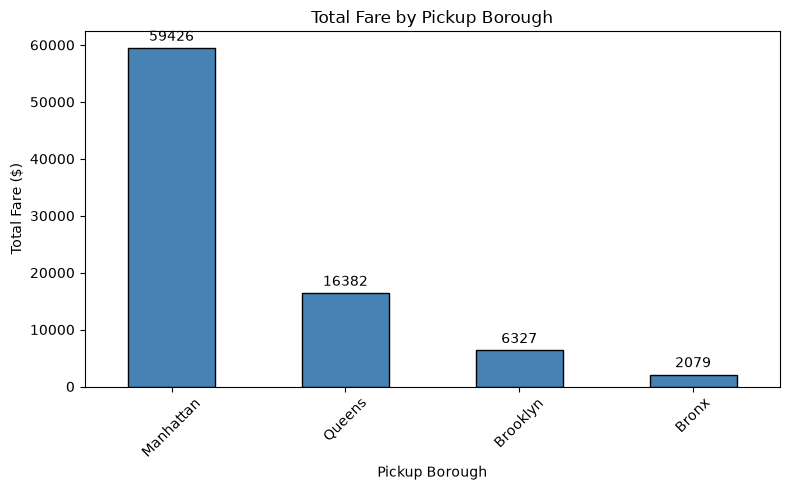

In [74]:
# Group by pickup_borough and sum the fare
borough_fare = df.groupby('pickup_borough')['fare'].sum().sort_values(ascending=False)
print(borough_fare)   # shows the numbers behind the chart

# Bar chart
ax = borough_fare.plot(kind='bar', figsize=(8, 5), color='steelblue', edgecolor='black')
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")
plt.xticks(rotation=45)

# Display the total fare value on top of each bar
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

Insights - The bar chart shows that Manhattan generates by far the highest total fare (about $59,426, roughly 70% of all fares), followed by Queens (about $16,382), Brooklyn (about $6,327) and the Bronx (about $2,079). This indicates that taxi activity and revenue are heavily concentrated in Manhattan, while the outer boroughs contribute much less

3. Pie Chart

1. A pie chart shows parts of a whole. Here the whole is all taxi trips, and each slice is one payment method's share of them.
2. It answers "how do passengers usually pay?" rather than "how much did they pay?", because it uses trip counts, not fare amounts.
3. It lets you see at a glance which payment method dominates and how big the smaller ones are.

payment
credit card    4621
cash           1812
Name: count, dtype: int64


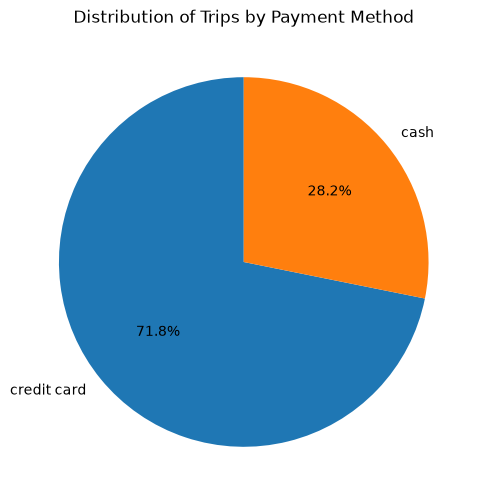

In [75]:
# Count the number of trips for each payment method
payment_counts = df['payment'].value_counts()
print(payment_counts)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Trips by Payment Method")
plt.show()

Insights - About 71.8% of trips were paid by credit card and 28.2% by cash, so credit card is the dominant payment method.
Only two payment types appear in this dataset, so the pie has two slices.

4. Histogram

1. The distribution is strongly right-skewed. The tallest bar is at the very start (roughly 2,300 trips under about 1.2 miles), and the second bar is nearly as tall (about 1,900 trips).
2. Most trips are short, under about 5 miles, and the counts drop off quickly after that.
3. A long, thin tail extends out to roughly 35 miles. These are rare long trips, likely airport or out-of-borough rides.

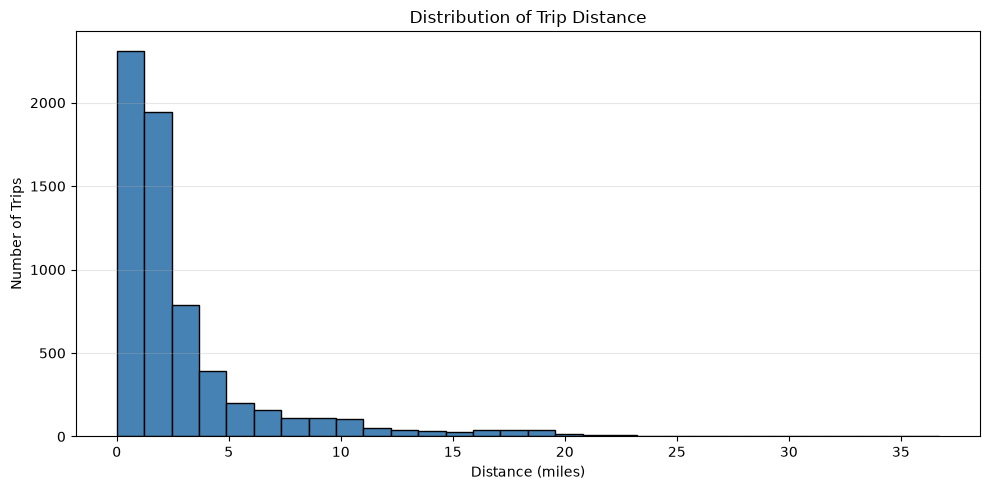

In [76]:
# Histogram of trip distance
plt.figure(figsize=(10, 5))
plt.hist(df['distance'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of Trip Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Trips")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Insight - "The histogram shows that most taxi trips are short, with the majority under 5 miles. The distribution is right-skewed, with a small number of long-distance trips forming a tail out to about 35 miles."

5. Box Plot

Create a box plot to compare the distribution of tip amounts across different pickup boroughs.

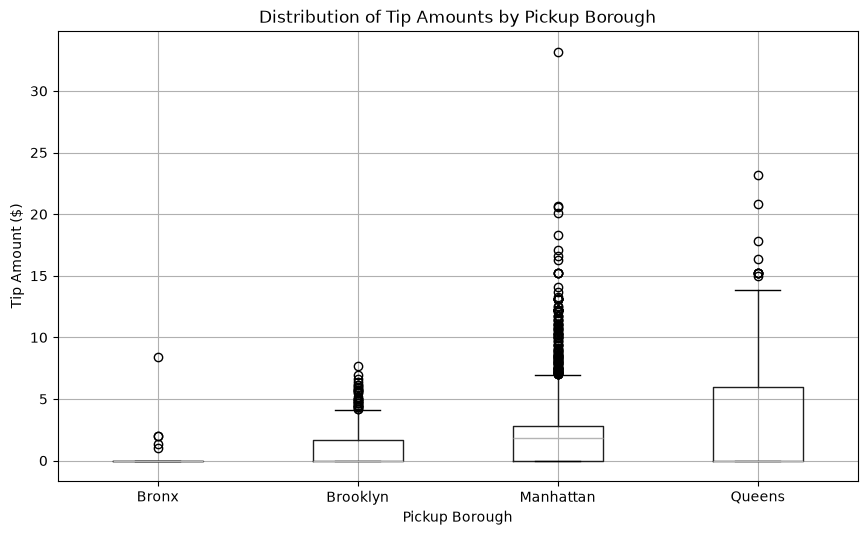

In [77]:
df.boxplot(column='tip', by='pickup_borough', figsize=(10, 6))

plt.suptitle("")
plt.title("Distribution of Tip Amounts by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount ($)")
plt.show()

The box plot shows that tip amounts vary across pickup boroughs. Manhattan has the highest typical tip amount, while Bronx has the lowest. The distributions are right-skewed, with some higher tip values appearing as outliers, especially in Manhattan and Queens.

Visualizations using Seaborn:

1. Count Plot

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

Create a count plot to compare the number of trips from each pickup borough.

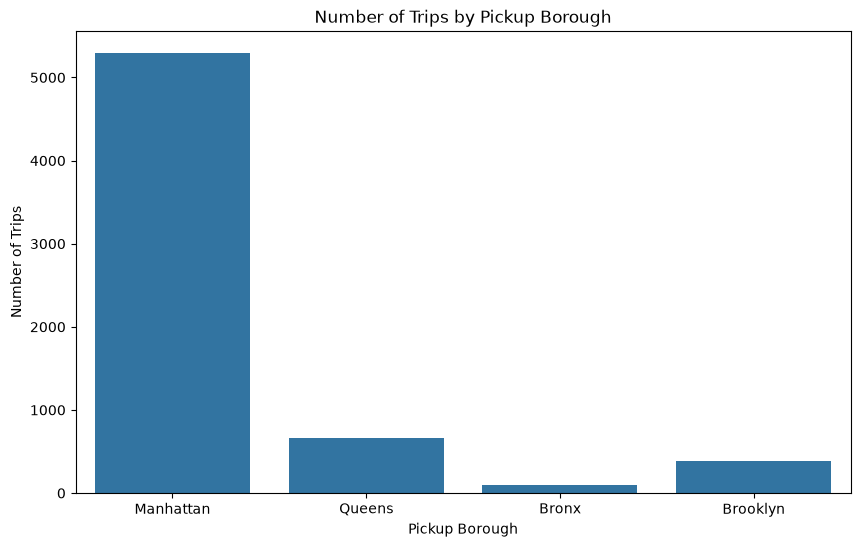

In [79]:
plt.figure(figsize=(10, 6))         # It says Python to Create a plotting area that is 10 inches wide and 6 inches tall.

sns.countplot(data=df, x='pickup_borough')

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")

plt.show()

Insight - Manhattan has the highest number of trips, while the Bronx has the lowest number of trips.

2. Scatter Plot

Create a scatter plot to check the relationship between trip distance and fare, and use different colors for each pickup borough.

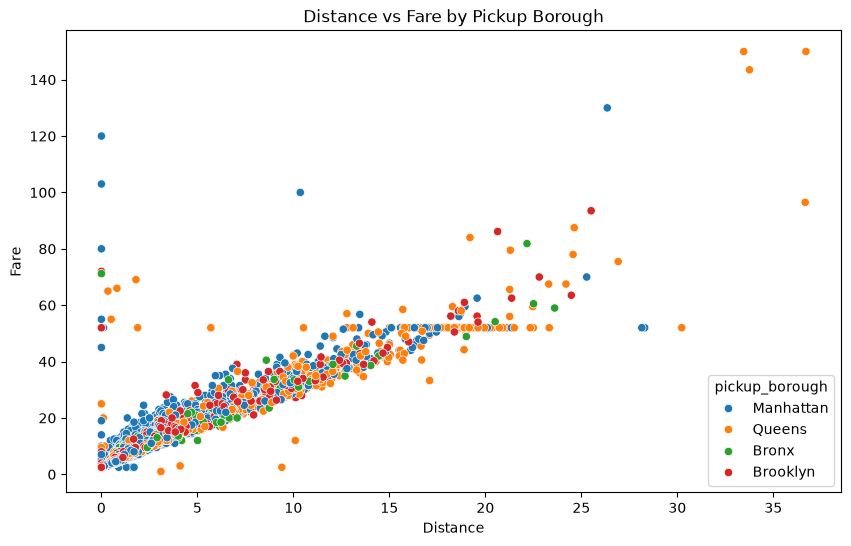

In [80]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough')

plt.title("Distance vs Fare by Pickup Borough")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.show()

Insights - Fare increases with distance, showing a clear positive relationship. Queens has 
the most high-fare, high-distance trips, likely airport-related, while a cluster around $52 
suggests a flat fare. A few Manhattan trips show high fares at very low distance, possibly 
data errors. Bronx and Brooklyn trips are mostly short and low-fare.

3. Heatmap

Create a correlation matrix for distance, fare, tip, tolls, and total, and use a heatmap to show how strongly these variables are related.

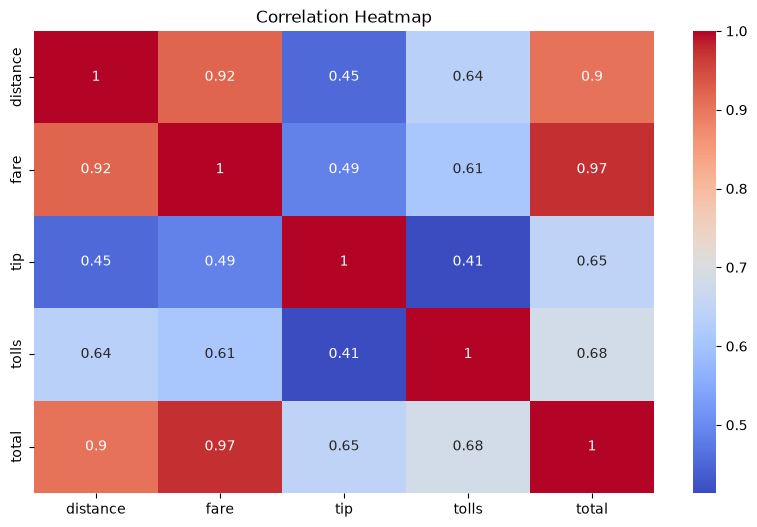

In [81]:
correlation = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Insights - Distance and fare are strongly correlated (0.92), and both are strongly linked 
to total (0.90 and 0.97), showing that distance and fare are the main drivers of total cost. 
Tip and tolls have only moderate correlations with the other variables (0.41-0.68), 
suggesting they are influenced by factors beyond just trip distance or fare.

4. Pair Plot

Create a pair plot to see the relationships between distance, fare, tip, and total, and use pickup_zone to show the different zones.

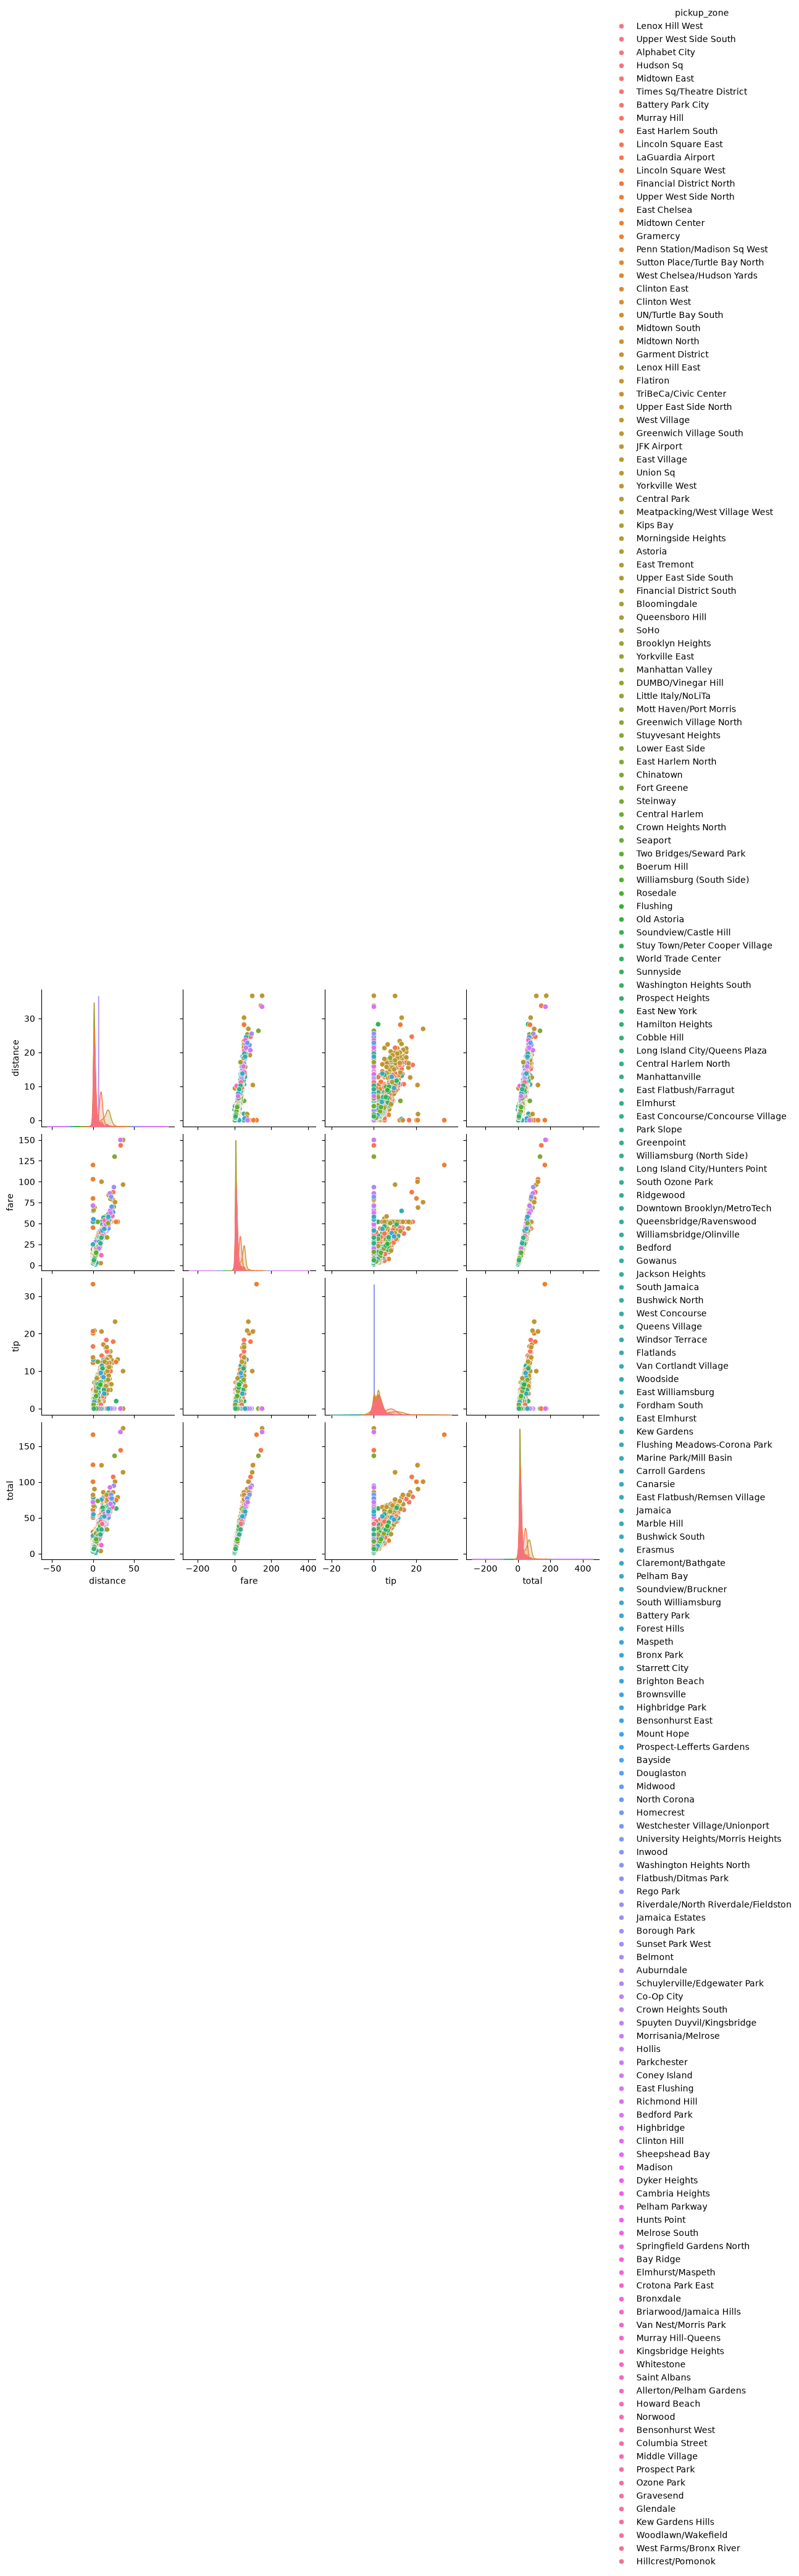

In [82]:
sns.pairplot(
    df[['distance', 'fare', 'tip', 'total', 'pickup_zone']],
    hue='pickup_zone'
)

plt.show()

Insights - The pairwise relationships confirm strong positive correlations between distance, 
fare, and total, consistent with earlier findings. However, with 100+ unique pickup zones, 
the color legend is too large to visually distinguish individual zones, making zone-level 
patterns hard to interpret from this plot alone.

In [83]:
print(top_zones.tolist())

['Midtown Center', 'Upper East Side South', 'Penn Station/Madison Sq West', 'Clinton East', 'Midtown East']


This chart shows the pairwise relationships for only the top 5 busiest pickup zones, 
making the color-coded comparison easier to read.

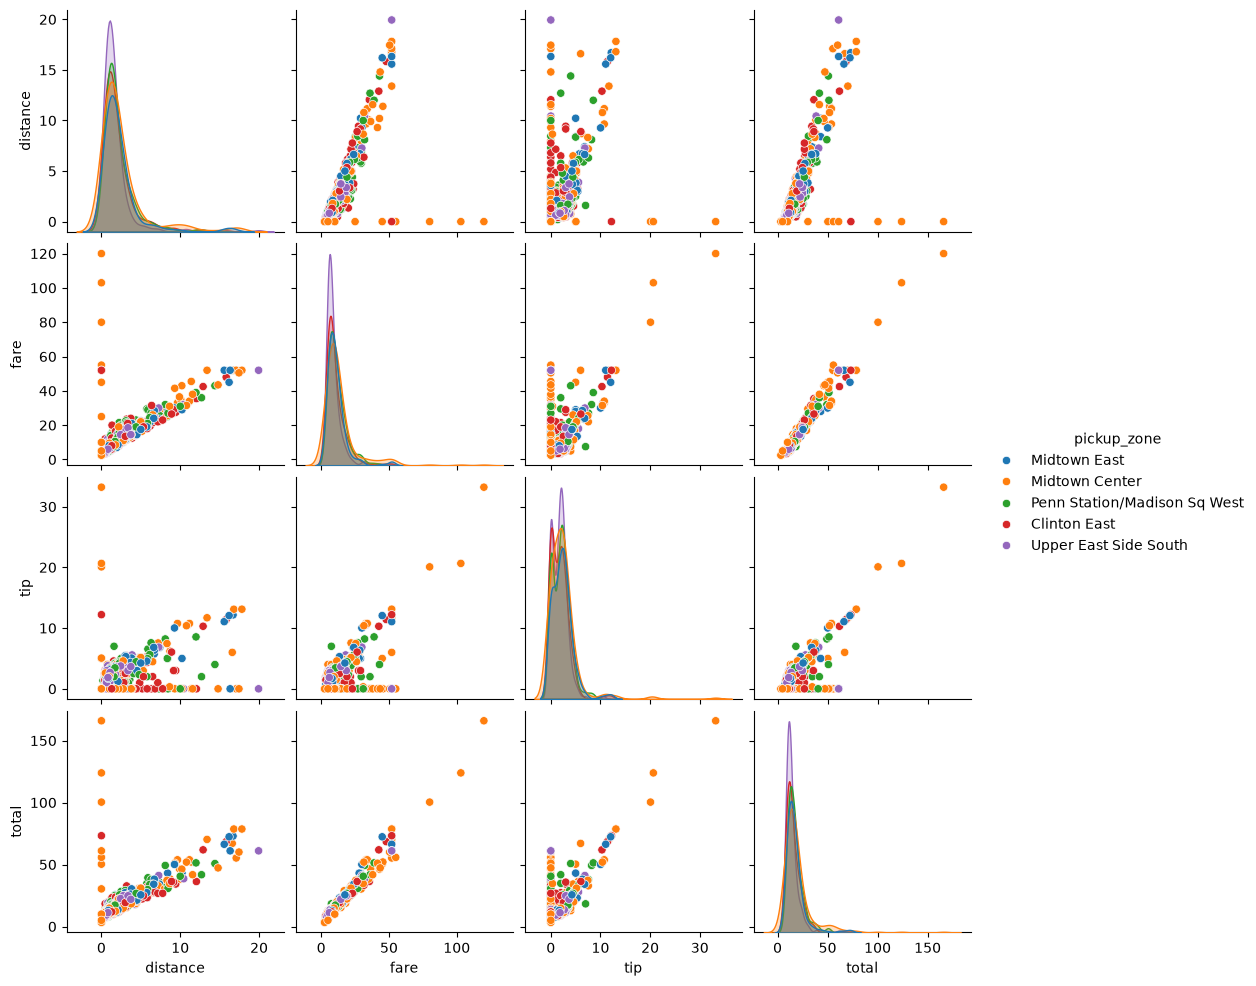

In [84]:
top_zones = df['pickup_zone'].value_counts().nlargest(5).index
subset = df[df['pickup_zone'].isin(top_zones)]

sns.pairplot(subset[['distance', 'fare', 'tip', 'total', 'pickup_zone']], hue='pickup_zone')
plt.show()

Insights - Restricting to the top 5 busiest pickup zones (all located in Manhattan — Midtown 
Center, Upper East Side South, Penn Station/Madison Sq West, Clinton East, and Midtown East) 
makes the color grouping readable. Distance, fare, and total continue to show strong positive 
correlations across zones. Tip amounts vary more within each zone and show a weaker relationship 
with the other variables. Notably, no airport zones appear among the top 5, suggesting these 
central Manhattan zones are high-volume, short-to-medium distance pickup areas rather than 
long-distance/high-fare trip generators.

5. Violin Plot

Show the distribution of fare for each payment method.

In [86]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough', 'date'],
      dtype='str')

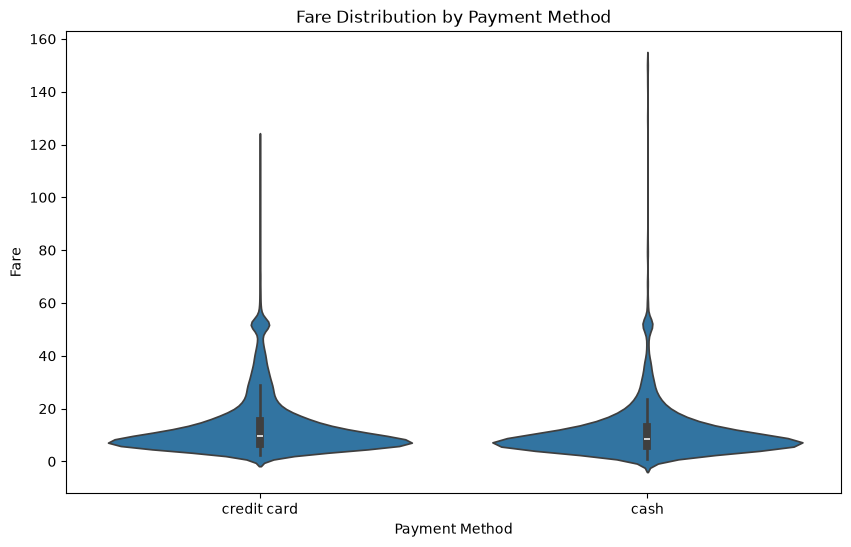

In [88]:
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x='payment', y='fare')

plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.show()

Insight: Fare distributions are nearly identical for credit card and cash payments. Most fares are concentrated between $0–30, with a median around $10–15. Both payment methods also show a noticeable concentration around $50. This suggests that the payment method has little effect on the fare amount.